# Classifying Penguins with Keras Day 2

In [87]:
!pip install plotly


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import optuna
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import plotly

In [2]:
from palmerpenguins import load_penguins
penguins = load_penguins()
penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [3]:
# drop Nan rows
penguins.dropna(inplace=True)

In [4]:
# defining X
penguins_x = pd.concat([penguins[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']], pd.get_dummies(penguins['sex'])], axis = 1)
# penguins_x = penguins_x[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'female', 'male']]
penguins_x

# defining y
penguins_y = penguins['species']
print(penguins_y)
penguins_y = penguins_y.astype('category').cat.codes.to_numpy()
penguins_y

# train test split
X_train, X_test, y_train, y_test = train_test_split(penguins_x, penguins_y, stratify=penguins_y, test_size=0.2, random_state=42)

y_train

0         Adelie
1         Adelie
2         Adelie
4         Adelie
5         Adelie
         ...    
339    Chinstrap
340    Chinstrap
341    Chinstrap
342    Chinstrap
343    Chinstrap
Name: species, Length: 333, dtype: str


array([2, 1, 2, 0, 0, 2, 2, 0, 0, 2, 0, 2, 1, 1, 0, 1, 2, 0, 2, 1, 0, 0,
       0, 2, 0, 2, 2, 1, 2, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 2, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2,
       1, 1, 1, 0, 2, 2, 0, 0, 2, 0, 2, 2, 2, 0, 1, 1, 2, 0, 2, 1, 2, 0,
       2, 0, 2, 0, 1, 2, 1, 0, 0, 0, 1, 1, 1, 2, 2, 0, 0, 2, 2, 1, 2, 1,
       2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 1, 1, 1, 2, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 2, 0, 0, 2, 0, 2, 2, 0, 2, 1, 1, 2, 0, 2, 2, 2, 2, 0, 0,
       2, 0, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 2, 2, 2, 1,
       1, 0, 2, 0, 2, 2, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 2, 0, 0, 1, 0, 0,
       1, 1, 0, 2, 0, 1, 0, 2, 0, 1, 2, 2, 2, 1, 1, 1, 2, 1, 0, 2, 0, 0,
       2, 2, 0, 2, 0, 0, 2, 0, 0, 1, 0, 1, 2, 1, 2, 2, 0, 2, 2, 2, 0, 2,
       2, 2, 0, 0, 0, 2, 1, 0, 0, 0, 0, 2, 1, 2, 2, 0, 0, 2, 0, 0, 1, 0,
       2, 0], dtype=int8)

In [5]:
# Scaling the data

scalar = StandardScaler()

# fit the scaler on the training data and transform both training and test data
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

X_train_scaled

array([[ 1.08239437,  0.16732502, -1.99231135,  0.83478089,  1.0461779 ,
        -1.0461779 ],
       [-0.21564233,  1.22705014,  1.25552054,  0.1212471 , -0.95586038,
         0.95586038],
       [ 2.19499725,  0.87989881, -0.52063753,  1.4769613 , -0.95586038,
         0.95586038],
       ...,
       [ 0.21703657,  0.02115604,  1.25552054, -0.37822656, -0.95586038,
         0.95586038],
       [ 1.453262  ,  0.80681432, -0.46989015,  1.33425454, -0.95586038,
         0.95586038],
       [-0.77194377, -1.91558298,  0.90028893, -0.80634683,  1.0461779 ,
        -1.0461779 ]], shape=(266, 6))

### Defining the model

In [6]:
#set random seed
tf.random.set_seed(42)

In [7]:
#construct the model
inputs = keras.Input(shape=(6,)) #6 inputs, input layer
x = layers.Dense(7, activation = 'relu')(inputs) #hidden layer 1
x = layers.Dense(5, activation = 'relu')(x) #hidden layer 2
outputs = layers.Dense(3, activation='softmax')(x) #output layer
model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

In [8]:
model.summary()

Model: "penguin_model"
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━┓
┃              ┃ Output    ┃ Par… ┃
┃ Layer (type) ┃ Shape     ┃    # ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━┩
│ input_layer  │ (None, 6) │    0 │
│ (InputLayer) │           │      │
├──────────────┼───────────┼──────┤
│ dense        │ (None, 7) │   49 │
│ (Dense)      │           │      │
├──────────────┼───────────┼──────┤
│ dense_1      │ (None, 5) │   40 │
│ (Dense)      │           │      │
├──────────────┼───────────┼──────┤
│ dense_2      │ (None, 3) │   18 │
│ (Dense)      │           │      │
└──────────────┴───────────┴──────┘
 Total params: 107 (428.00 B)
 Trainable params: 107 (428.00 B)
 Non-trainable params: 0 (0.00 B)


### Model training parameters (compile) & model training (fit)

In [9]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history = model.fit(X_train_scaled, y_train, 
                    batch_size = 128, 
                    epochs=10, #10 epochs
                    validation_split=0.2, 
                    verbose=1)

scores = model.evaluate(X_test_scaled, y_test, verbose = 1)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5236 - loss: 1.0637 - val_accuracy: 0.6111 - val_loss: 1.0379
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5472 - loss: 1.0598 - val_accuracy: 0.6296 - val_loss: 1.0338
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5755 - loss: 1.0559 - val_accuracy: 0.6296 - val_loss: 1.0297
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5802 - loss: 1.0520 - val_accuracy: 0.6296 - val_loss: 1.0254
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5708 - loss: 1.0480 - val_accuracy: 0.6667 - val_loss: 1.0211
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5755 - loss: 1.0440 - val_accuracy: 0.6667 - val_loss: 1.0171
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5849 - loss: 1.0401 - val_accuracy: 0.6667 - val_loss: 1.0131
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5991 - loss: 1.0360 - val_accuracy: 0.6852 - val_loss: 1.0091


### Evaluating on the test data

In [10]:
# evaluate the model using the test set
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1) 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\n Test Set Evaluation:") 
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

 Test Set Evaluation:
Test Accuracy: 0.5522
Test Precision: 0.4273
Test Recall: 0.5522
Test F1 Score: 0.4807
Test ROC AUC Score: 0.7704


/Users/donyabehroozi/Documents/gsb545/GSB-545/tf_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Evaluating model training using loss and accuracy

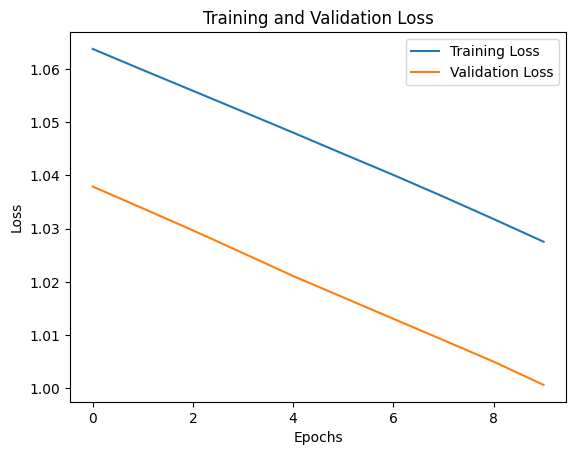

In [11]:
# plot loss vs val_loss
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

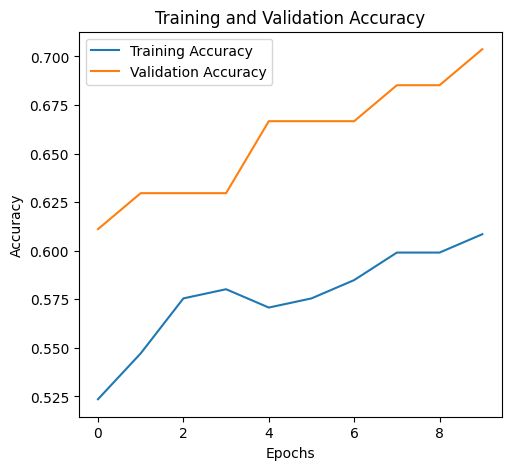

In [12]:
# plot the training and validation accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))     
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()    

### Model variability

Define, compile and train the model 3 times and see how your training and validation curves change. Are they the same or different? Why is this happening?

They are different. This is because the starting weights of my models are changing each time I define, compile, and train the model.

### Setting a random seed

How does setting the tf random seed affect the training and validation curves?

There is less variability in the training and validation curves each time I define, compile, and train the model. The training loss is generally higher than the validation loss, and the training accuracy is lower than the validation accuracy.

Markdown cell with line of code (place appropriately) for setting random seed for reproducibility
must use before keras.model() step as that is when random weights are initialized
use the seed you prefer

tf.random.set_seed(42)

### Modifying the hidden layers

Try **three** different configurations for the hidden layers. You are welcome to add or remove layers, to try different layer strategies (funnel, flat, etc ) and to vary the number of neurons. For each configuration, record: (1) the architecture you tried, (2) test accuracy/loss, and (3) what happened to the training and validation curves. What seemed to work best?

In [13]:
#construct the model
inputs = keras.Input(shape=(6,)) #6 inputs, input layer
x = layers.Dense(64, activation = 'relu')(inputs) #hidden layer 1
x = layers.Dense(32, activation = 'relu')(x) #hidden layer 2
x = layers.Dense(16, activation = 'relu')(x) #hidden layer 3
outputs = layers.Dense(3, activation='softmax')(x) #output layer
model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

In [14]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history = model.fit(X_train_scaled, y_train, 
                    batch_size = 128, 
                    epochs=10, #10 epochs
                    validation_split=0.2, 
                    verbose=1)

scores = model.evaluate(X_test_scaled, y_test, verbose = 1)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.3915 - loss: 1.0562 - val_accuracy: 0.4815 - val_loss: 1.0241
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5142 - loss: 1.0197 - val_accuracy: 0.5556 - val_loss: 0.9829
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5943 - loss: 0.9833 - val_accuracy: 0.6481 - val_loss: 0.9434
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6651 - loss: 0.9478 - val_accuracy: 0.7222 - val_loss: 0.9069
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7123 - loss: 0.9145 - val_accuracy: 0.7407 - val_loss: 0.8720
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7358 - loss: 0.8824 - val_accuracy: 0.7963 - val_loss: 0.8384
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7547 - loss: 0.8502 - val_accuracy: 0.7963 - val_loss: 0.8038
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7642 - loss: 0.8175 - val_accuracy: 0.8148 - val_loss: 0.7688


In [15]:
# evaluate the model using the test set (never seen the data, extra split off the validation data)
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1) 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\n Test Set Evaluation:") 
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

 Test Set Evaluation:
Test Accuracy: 0.7612
Test Precision: 0.6157
Test Recall: 0.7612
Test F1 Score: 0.6778
Test ROC AUC Score: 0.9588


/Users/donyabehroozi/Documents/gsb545/GSB-545/tf_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


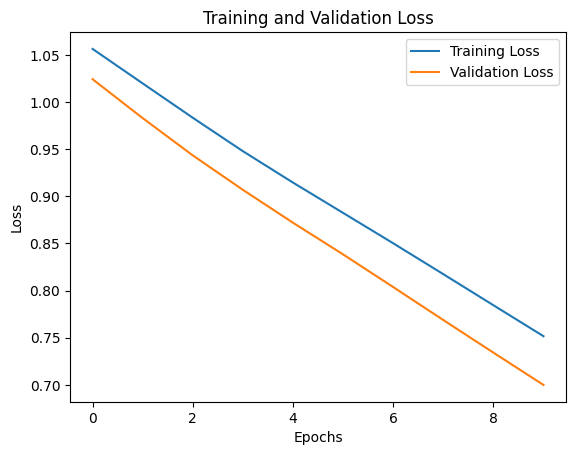

In [16]:
# plot loss vs val_loss
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

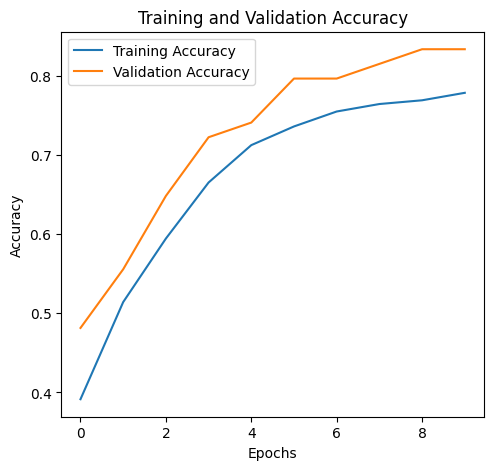

In [17]:
# plot the training and validation accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))     
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()    

**Round 1**

Artchitecture: Funnel (16->8->3)

Test accuracy = 0.6418

Validation loss lower than training loss over the epochs. Training accuracy higher than validation accuracy after epoch 4. Training accuracy gradually increases, validation accuracy does not change much

**Round 2**

Artchitecture: Flat (12->12->3)

Test accuracy = 0.4179

Training loss lower than validation loss over the epochs, but the curves are closer together now. Training accuracy is lower than validation accuracy through all epochs. Both curves show training and validation accuracy gradually increasing over the epochs.

**Round 3**

Artchitecture: Funnel (64->32->16->3)

Test accuracy = 0.9552

Training loss and validation loss curves are very close to each other over the epochs. Up to epoch 6, training loss is a bit higher than validation loss. Training and validation accuracy increases much faster from epoch 0 to 5, but flatten out after that point.

Overall, adding an extra hidden layer, increasing the number of neurons, and using a funnel architecture made the model perform the best. 


### Modifying the training cycles (epochs)

Vary the number of epochs. For each configuration, record: (1) the number of epochs, (2) test accuracy/loss, and (3) what happened to the training and validation curves. What was the minimum number of epochs needed for reliable model performance?

In [18]:
#construct the model
inputs = keras.Input(shape=(6,)) #6 inputs, input layer
x = layers.Dense(7, activation = 'relu')(inputs) #hidden layer 1
x = layers.Dense(5, activation = 'relu')(x) #hidden layer 2
outputs = layers.Dense(3, activation='softmax')(x) #output layer
model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

In [19]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history = model.fit(X_train_scaled, y_train, 
                    batch_size = 128, 
                    epochs=75, #75 epochs
                    validation_split=0.2, 
                    verbose=1)

scores = model.evaluate(X_test_scaled, y_test, verbose = 1)

Epoch 1/75
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.3538 - loss: 1.1039 - val_accuracy: 0.3889 - val_loss: 1.0627
Epoch 2/75
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3632 - loss: 1.0931 - val_accuracy: 0.3889 - val_loss: 1.0518
Epoch 3/75
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3726 - loss: 1.0825 - val_accuracy: 0.3889 - val_loss: 1.0411
Epoch 4/75
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3774 - loss: 1.0721 - val_accuracy: 0.4074 - val_loss: 1.0304
Epoch 5/75
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3915 - loss: 1.0619 - val_accuracy: 0.4074 - val_loss: 1.0196
Epoch 6/75
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3962 - loss: 1.0518 - val_accuracy: 0.4259 - val_loss: 1.0086
Epoch 7/75
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4057 - loss: 1.0419 - val_accuracy: 0.4259 - val_loss: 0.9978
Epoch 8/75
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4057 - loss: 1.0321 - val_accuracy: 0.4259 - val_loss: 0.9870


In [20]:
# evaluate the model using the test set (never seen the data, extra split off the validation data)
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1) 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\n Test Set Evaluation:") 
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x14c041b20> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

 Test Set Evaluation:
Test Accuracy: 0.7910
Test Precision: 0.6368
Test Recall: 0.7910
Test F1 Score: 0.7025
Test ROC AUC Score: 0.9595


/Users/donyabehroozi/Documents/gsb545/GSB-545/tf_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


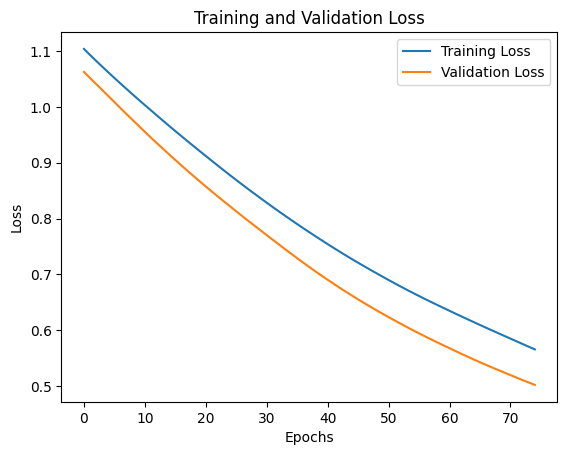

In [21]:
# plot loss vs val_loss
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

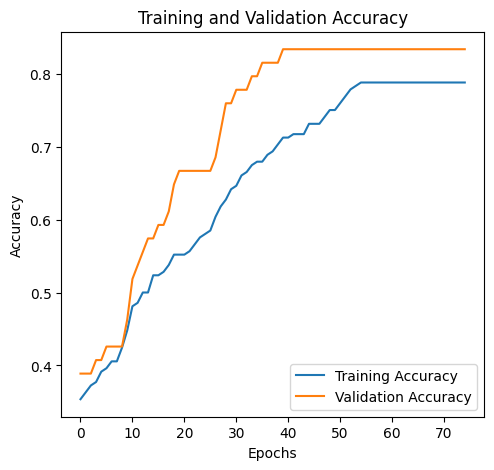

In [22]:
# plot the training and validation accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))     
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()    

**Round 1**

20 epochs

Test Accuracy = 0.5224

Validation and training loss curves slowly decreasing over the epochs. Validation loss is much lower than the training loss. Both training and validation accuracy gradually increase over the epochs. Validation accuracy is much higher than the training accuracy. The training accuracy curve increases slower than the validation accuracy curve over the epochs.

**Round 2**

50 epochs

Test Accuracy = 0.7910

Validation and training loss curves gradually decrease over the epochs. Validation loss and training loss curves are much closer now. Validation loss is lower than training loss near epoch 30. Both training and validation accuracy exponentially increase until epoch 20, then go flat. Validation accuracy is slightly higher than the training accuracy after epoch 20.

**Round 2**

75 epochs

Test Accuracy = 0.9701

Validation and training loss curves gradually decrease over the epochs. Validation loss and training loss curves are much closer, like in round 2. Both training and validation accuracy increase quickly until epoch 20, then go relatively flat. Training accuracy is primarily slightly higher than the validation accuracy between epochs 0 and 40.


### Early stopping, l2 regularization and dropout 

Doing all these for peguins is probably overkill!

In [81]:
# sample model 

tf.random.set_seed(42)  # set seed for reproducibility

inputs = keras.Input(shape=(6,))  # 6 input features

x = layers.Dense(
    7,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 penalty on weights
)(inputs)
x = layers.Dropout(0.2)(x)  # randomly drop 20% of neurons during training

x = layers.Dense(
    5,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 applied again
)(x)
x = layers.Dropout(0.2)(x)  # dropout applied per layer

x = layers.Dense(
    3,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 on final hidden layer
)(x)
x = layers.Dropout(0.2)(x)  # dropout again (often not needed this deep)

outputs = layers.Dense(3, activation="softmax")(x)  # 3-class output → probabilities

model = keras.Model(inputs=inputs, outputs=outputs)  # build model (initialize weights)

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # multiclass loss
    optimizer=keras.optimizers.Adam(),  # adaptive optimizer
    metrics=["accuracy"]  # track accuracy
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",  # watch validation loss
    patience=5,  # stop after 5 epochs without improvement
    restore_best_weights=True  # keep best-performing weights
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,  # maximum training length
    batch_size=64,
    validation_split=0.2,  # hold out 10% for validation
    callbacks=[early_stop],  # apply early stopping
    verbose=1
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.4245 - loss: 1.2923 - val_accuracy: 0.4444 - val_loss: 1.2698
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4481 - loss: 1.2727 - val_accuracy: 0.4444 - val_loss: 1.2566
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4528 - loss: 1.2908 - val_accuracy: 0.4444 - val_loss: 1.2443
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4717 - loss: 1.2634 - val_accuracy: 0.4444 - val_loss: 1.2325
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4151 - loss: 1.2818 - val_accuracy: 0.4444 - val_loss: 1.2208
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4717 - loss: 1.2492 - val_accuracy: 0.4444 - val_loss: 1.2101
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4670 - loss: 1.2242 - val_accuracy: 0.4444 - val_loss: 1.1998
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4340 - loss: 1.2259 - val_accuracy: 0.4444 - val_loss: 1.1899

### Tuning with Optuna

Adjust the code below to have the validation size, epochs and verbosity you found best from above. Then tune your model. You are welcome to increase the number of trials or to add parameters if you desire. Make sure the outputs of your cells are displayed. Then build a final model using your optimized parameters and predict on the test set.

In [23]:
# tuning the model with Optuna

def objective(trial):
    num_layers = trial.suggest_int("num_layers", 1, 3)  # number of hidden layers
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)  # log scale for LR
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])  # common batch sizes

    inputs = keras.Input(shape=(6,))  # 6 input features
    x = inputs

    for i in range(num_layers):
        units = trial.suggest_int(f"num_units_layer_{i+1}", 4, 32)  # neurons per layer
        x = layers.Dense(units, activation="relu")(x)  # hidden layer

    outputs = layers.Dense(3, activation="softmax")(x)  # 3 classes → softmax output
    model = keras.Model(inputs=inputs, outputs=outputs)  # build model

    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # classification loss
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),  # optimizer with tuned LR
        metrics=["accuracy"],  # track accuracy
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",  # watch validation loss
        patience=5,  # stop after 5 epochs without improvement
        restore_best_weights=True  # keep best model weights
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        batch_size=batch_size,
        epochs=75,  # max training epochs
        validation_split=0.2,  # validation portion of training data
        verbose=1,  # suppress output during tuning
        callbacks=[early_stop]  # apply early stopping
    )

    return min(history.history["val_loss"])  # objective = best validation loss


study = optuna.create_study(direction="minimize")  # minimize validation loss
study.optimize(objective, n_trials=20)  # run 20 trials (20 models)

print("Best validation loss:", study.best_value)
print("Best parameters:", study.best_params)


[I 2026-05-14 13:54:44,924] A new study created in memory with name: no-name-0cacce9d-253d-45af-9f7a-ec42c341ffc8


Epoch 1/75
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5896 - loss: 0.9994 - val_accuracy: 0.8519 - val_loss: 0.9022
Epoch 2/75
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7783 - loss: 0.8951 - val_accuracy: 0.8519 - val_loss: 0.7993
Epoch 3/75
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8208 - loss: 0.8040 - val_accuracy: 0.8704 - val_loss: 0.7068
Epoch 4/75
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8443 - loss: 0.7165 - val_accuracy: 0.8704 - val_loss: 0.6232
Epoch 5/75
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8726 - loss: 0.6341 - val_accuracy: 0.9259 - val_loss: 0.5455
Epoch 6/75
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8868 - loss: 0.5565 - val_accuracy: 0.9444 - val_loss: 0.4773
Epoch 7/75
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9009 - loss: 0.4850 - val_accuracy: 0.9630 - val_loss: 0.4167
Epoch 8/75
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9104 - loss: 0.4210 - val_accuracy: 0.9630 - val_loss:

[I 2026-05-14 13:54:47,828] Trial 0 finished with value: 0.03641655296087265 and parameters: {'num_layers': 2, 'learning_rate': 0.0008577925884456944, 'batch_size': 16, 'num_units_layer_1': 22, 'num_units_layer_2': 21}. Best is trial 0 with value: 0.03641655296087265.


Epoch 1/75
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4623 - loss: 1.0276 - val_accuracy: 0.6481 - val_loss: 0.8726
Epoch 2/75
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7500 - loss: 0.7689 - val_accuracy: 0.8519 - val_loss: 0.6619
Epoch 3/75
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8726 - loss: 0.5899 - val_accuracy: 0.8519 - val_loss: 0.5062
Epoch 4/75
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8962 - loss: 0.4472 - val_accuracy: 0.8889 - val_loss: 0.3778
Epoch 5/75
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9198 - loss: 0.3295 - val_accuracy: 0.9444 - val_loss: 0.2724
Epoch 6/75
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9481 - loss: 0.2393 - val_accuracy: 0.9630 - val_loss: 0.1957
Epoch 7/75
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9811 - loss: 0.1732 - val_accuracy: 0.9815 - val_loss: 0.1428
Epoch 8/75
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9811 - loss: 0.1259 - val_accuracy: 0.9815 - val_loss:

[I 2026-05-14 13:54:49,501] Trial 1 finished with value: 0.029604224488139153 and parameters: {'num_layers': 2, 'learning_rate': 0.0019092253798511745, 'batch_size': 16, 'num_units_layer_1': 17, 'num_units_layer_2': 21}. Best is trial 1 with value: 0.029604224488139153.


...

Epoch 1/75
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5330 - loss: 0.9557 - val_accuracy: 0.7593 - val_loss: 0.7797
Epoch 2/75
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7830 - loss: 0.7018 - val_accuracy: 0.8333 - val_loss: 0.5417
Epoch 3/75
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8019 - loss: 0.4887 - val_accuracy: 0.8704 - val_loss: 0.3398
Epoch 4/75
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8396 - loss: 0.3274 - val_accuracy: 0.9259 - val_loss: 0.2249
Epoch 5/75
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9104 - loss: 0.2255 - val_accuracy: 0.9630 - val_loss: 0.1651
Epoch 6/75
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9623 - loss: 0.1532 - val_accuracy: 0.9630 - val_loss: 0.1230
Epoch 7/75
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9858 - loss: 0.0991 - val_accuracy: 0.9815 - val_loss: 0.0837
Epoch 8/75
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9858 - loss: 0.0622 - val_accuracy: 0.9815 - val_loss: 0.0558
Epoch 9

[I 2026-05-14 13:55:20,733] Trial 18 finished with value: 0.03126729279756546 and parameters: {'num_layers': 3, 'learning_rate': 0.004931697390820133, 'batch_size': 32, 'num_units_layer_1': 15, 'num_units_layer_2': 13, 'num_units_layer_3': 32}. Best is trial 12 with value: 0.008416884578764439.


Epoch 1/75
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5047 - loss: 1.0250 - val_accuracy: 0.8333 - val_loss: 0.7778
Epoch 2/75
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7925 - loss: 0.6811 - val_accuracy: 0.8333 - val_loss: 0.4726
Epoch 3/75
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8113 - loss: 0.4428 - val_accuracy: 0.8889 - val_loss: 0.3070
Epoch 4/75
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8585 - loss: 0.3105 - val_accuracy: 0.9630 - val_loss: 0.2246
Epoch 5/75
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9340 - loss: 0.2224 - val_accuracy: 0.9815 - val_loss: 0.1654
Epoch 6/75
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9811 - loss: 0.1533 - val_accuracy: 0.9815 - val_loss: 0.1201
Epoch 7/75
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9811 - loss: 0.1037 - val_accuracy: 0.9815 - val_loss: 0.0911
Epoch 8/75
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9906 - loss: 0.0716 - val_accuracy: 0.9815 - val_loss:

[I 2026-05-14 13:55:21,884] Trial 19 finished with value: 0.042393747717142105 and parameters: {'num_layers': 2, 'learning_rate': 0.0036610071485230072, 'batch_size': 16, 'num_units_layer_1': 23, 'num_units_layer_2': 8}. Best is trial 12 with value: 0.008416884578764439.


Best validation loss: 0.008416884578764439
Best parameters: {'num_layers': 2, 'learning_rate': 0.009424163995606177, 'batch_size': 16, 'num_units_layer_1': 12, 'num_units_layer_2': 4}


<positron-console-cell-26>:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
<positron-console-cell-26>:3: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
<positron-console-cell-26>:4: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.


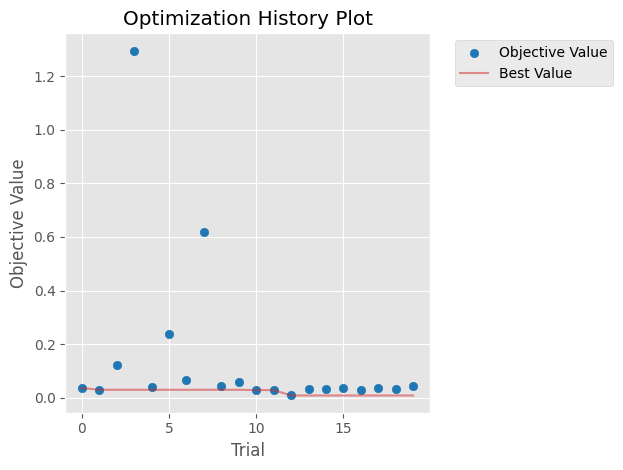

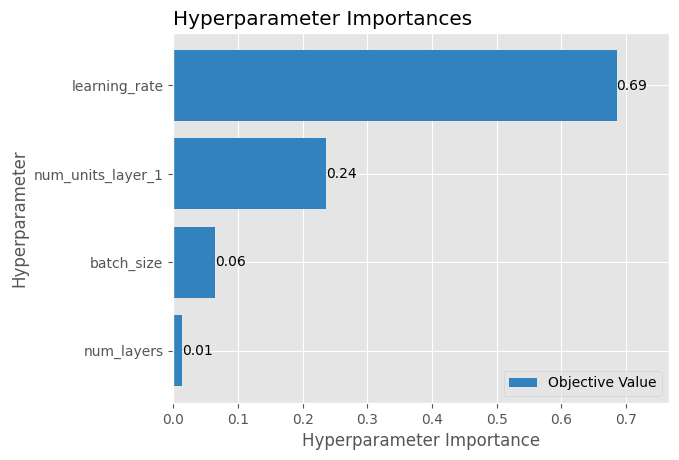

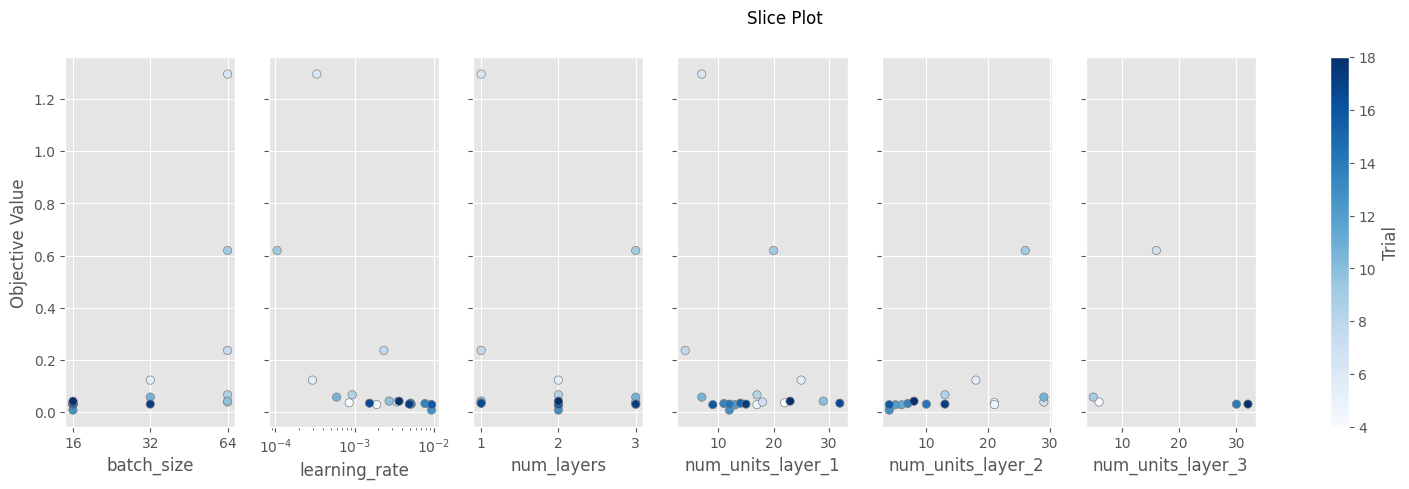

In [26]:
# visualizing Optuna results
optuna.visualization.matplotlib.plot_optimization_history(study)
optuna.visualization.matplotlib.plot_param_importances(study)
optuna.visualization.matplotlib.plot_slice(study)

import matplotlib.pyplot as plt
plt.show()

In [27]:
# Building the best model from Optuna results
best_params = study.best_params
num_layers = best_params["num_layers"]
learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]  
inputs = keras.Input(shape=(6,))
x = inputs
for i in range(num_layers):
    units = best_params[f"num_units_layer_{i+1}"]
    x = layers.Dense(units, activation="relu")(x)
outputs = layers.Dense(3, activation="softmax")(x)
best_model = keras.Model(inputs=inputs, outputs=outputs)
best_model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    metrics=["accuracy"],
)   
history = best_model.fit(X_train_scaled, y_train, batch_size=batch_size, epochs=50, validation_split=0.2, verbose=1, callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)])
scores = best_model.evaluate(X_test_scaled, y_test, verbose=1)  

# evaluate the best model using the test set
y_pred_prob = best_model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\n Best Model Test Set Evaluation:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6509 - loss: 0.9766 - val_accuracy: 0.8148 - val_loss: 0.8031
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7877 - loss: 0.6760 - val_accuracy: 0.8333 - val_loss: 0.4739
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7925 - loss: 0.4434 - val_accuracy: 0.8704 - val_loss: 0.2743
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8491 - loss: 0.2810 - val_accuracy: 0.9815 - val_loss: 0.1744
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9670 - loss: 0.1589 - val_accuracy: 0.9815 - val_loss: 0.1099
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9858 - loss: 0.0833 - val_accuracy: 0.9815 - val_loss: 0.0686
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9906 - loss: 0.0496 - val_accuracy: 0.9815 - val_loss: 0.0495
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9906 - loss: 0.0339 - val_accuracy: 0.9815 - val_loss: